# Spectral Feature Extraction

Spectral features summarise the frequency-domain content of each analysis frame. They are widely used in music information retrieval (MIR) and as input features for machine-learning models.

| Function | Description |
| --- | --- |
| `spectral_centroid` | **Frequency-weighted mean** of the magnitude spectrum per frame: `C = Σ(f · |X[f]|) / Σ|X[f]|`. Tracks perceived brightness — a chirp rising in frequency produces a rising centroid. Units: Hz. |
| `spectral_flux` | **Frame-to-frame magnitude difference**: `F[n] = ‖|X[n]| − |X[n−1]|‖₂`. High flux indicates onsets (sudden spectral change) or noise (random frame-to-frame variation). Units: arbitrary energy scale. |


In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import matplotlib.pyplot as plt

from python.generators import generate_chirp, generate_white_noise
from python.spectral import spectral_centroid, spectral_flux

FS = 44100

%matplotlib inline
plt.rcParams['figure.dpi'] = 110

## Visualisation

Centroid and flux for a logarithmic chirp (100 → 8000 Hz) vs white noise (1 s at 44 100 Hz, frame = 2048, hop = 512).

**2 × 2 grid:**

**Top row — spectral centroid over time:**
- **Left — chirp:** centroid rises monotonically from ~100 Hz to ~8000 Hz, tracking the instantaneous frequency of the sweep; the logarithmic sweep produces a near-linear rise on the log-frequency scale
- **Right — noise:** centroid fluctuates around ~3–4 kHz (the expected centroid of flat white noise from DC to Nyquist at 44 100 Hz is ~11 kHz; windowed frames and the RFFT spectral shape shift this lower); frame-to-frame variation is the spectral estimation variance

**Bottom row — spectral flux over time:**
- **Left — chirp flux:** relatively low and smooth; the chirp changes gradually so consecutive magnitude spectra differ only a little
- **Right — noise flux:** uniformly high and highly variable; each noise frame is statistically independent, so every frame transition is a large magnitude change

**Use cases:** centroid is used for brightness tracking and vowel detection; flux is the foundation of onset detection algorithms.


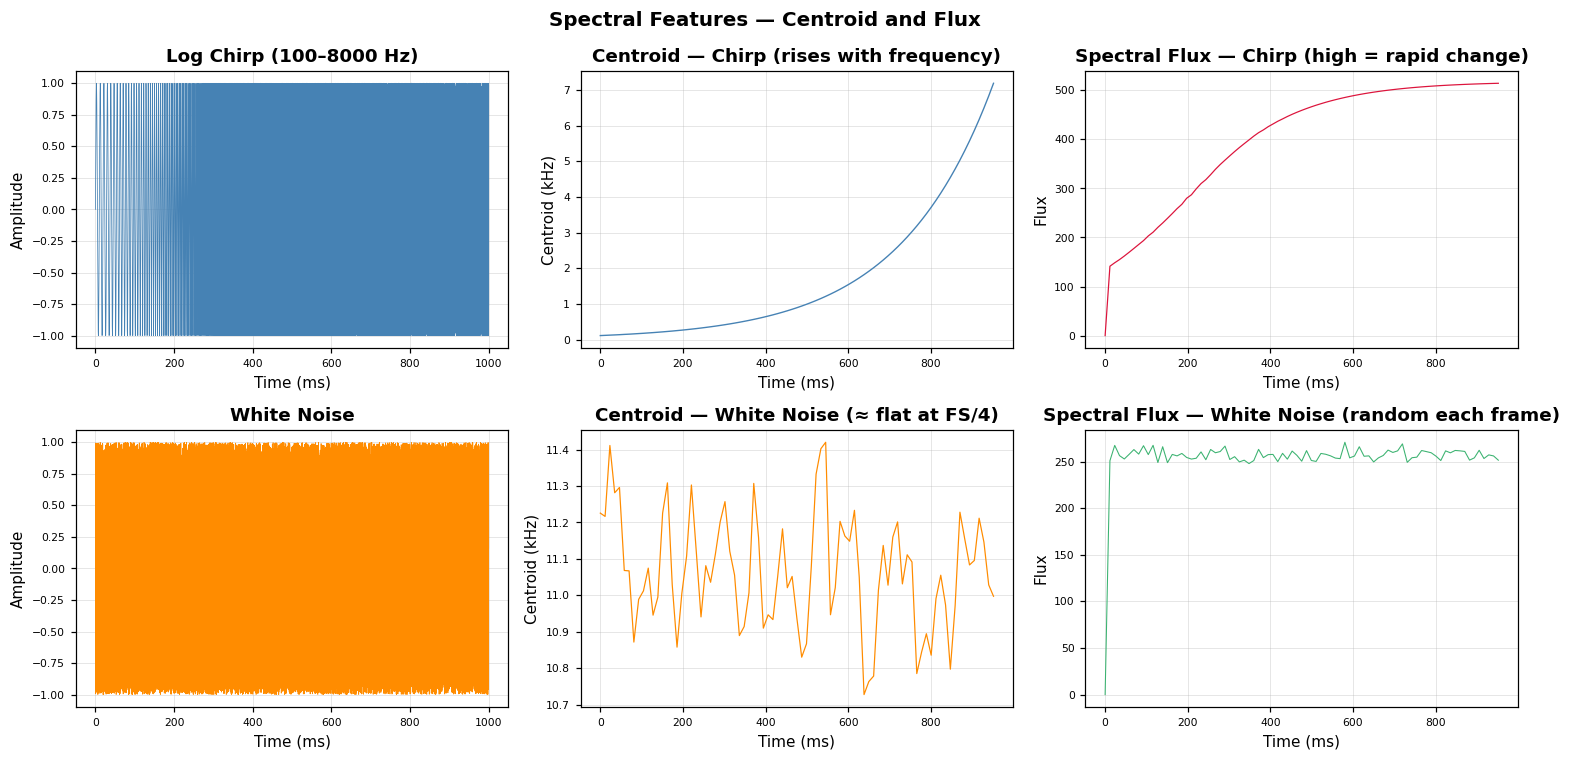

In [2]:
FS = 44100
DURATION = 1.0
FRAME = 2048
HOP = 512

_, chirp = generate_chirp(f_start=100.0, f_end=8000.0, fs=FS, duration=DURATION, method="logarithmic")
_, noise = generate_white_noise(fs=FS, duration=DURATION, seed=0)

chirp_centroid = spectral_centroid(chirp, fs=FS, frame_size=FRAME, hop_size=HOP)
noise_centroid = spectral_centroid(noise, fs=FS, frame_size=FRAME, hop_size=HOP)
chirp_flux = spectral_flux(chirp, frame_size=FRAME, hop_size=HOP)
noise_flux = spectral_flux(noise, frame_size=FRAME, hop_size=HOP)

frame_times = np.arange(len(chirp_centroid)) * HOP / FS * 1000
t_ms = np.arange(len(chirp)) / FS * 1000

fig, axes = plt.subplots(2, 3, figsize=(14, 7))

axes[0, 0].plot(t_ms, chirp, linewidth=0.5, color="steelblue")
axes[0, 0].set_title("Log Chirp (100–8000 Hz)", fontweight="bold")
axes[0, 0].set_xlabel("Time (ms)")
axes[0, 0].set_ylabel("Amplitude")

axes[0, 1].plot(frame_times, chirp_centroid / 1000, linewidth=0.9, color="steelblue")
axes[0, 1].set_title("Centroid — Chirp (rises with frequency)", fontweight="bold")
axes[0, 1].set_xlabel("Time (ms)")
axes[0, 1].set_ylabel("Centroid (kHz)")

axes[0, 2].plot(frame_times, chirp_flux, linewidth=0.8, color="crimson")
axes[0, 2].set_title("Spectral Flux — Chirp (high = rapid change)", fontweight="bold")
axes[0, 2].set_xlabel("Time (ms)")
axes[0, 2].set_ylabel("Flux")

axes[1, 0].plot(t_ms, noise, linewidth=0.5, color="darkorange")
axes[1, 0].set_title("White Noise", fontweight="bold")
axes[1, 0].set_xlabel("Time (ms)")
axes[1, 0].set_ylabel("Amplitude")

axes[1, 1].plot(frame_times, noise_centroid / 1000, linewidth=0.8, color="darkorange")
axes[1, 1].set_title("Centroid — White Noise (≈ flat at FS/4)", fontweight="bold")
axes[1, 1].set_xlabel("Time (ms)")
axes[1, 1].set_ylabel("Centroid (kHz)")

axes[1, 2].plot(frame_times, noise_flux, linewidth=0.7, color="mediumseagreen")
axes[1, 2].set_title("Spectral Flux — White Noise (random each frame)", fontweight="bold")
axes[1, 2].set_xlabel("Time (ms)")
axes[1, 2].set_ylabel("Flux")

for ax in axes.flatten():
    ax.tick_params(labelsize=7)
    ax.grid(True, linewidth=0.4, alpha=0.5)

fig.suptitle("Spectral Features — Centroid and Flux", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()